### **5.1 K-Means Clustering**

**Syntax:**
```bash
model = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
```

**Parameters (simple language)**
* n_clusters ⭐
    * number of groups (clusters) to form
* init → 'k-means++', 'random'
    * method to choose initial centers
    * 'k-means++' = better (default)
* n_init
    * number of times algorithm runs with different initial points
    * best result is chosen
* max_iter
    * maximum iterations for convergence
* random_state
    * for same results every time (reproducibility)

**Methods:**
* model.fit(X)
* model.predict(X)
* model.fit_predict(X)

**Important Attributes**
1. cluster_centers_ -> To see where clusters are located
2. labels_ -> Tells to which cluster each data point belongs
    * For every point → gives a number(cluster labeling like 0, 1, 2, …)
3. inertia_ -> It is the total distance of all points from their cluster center
    * Lower value = better clustering ✅
    * Higher value = worse clustering ❌

**Limitation:**
* Need to choose K manually

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

# Small dataset
X = np.array([
    [1, 2], [1, 3], [2, 2],
    [8, 8], [9, 8], [8, 9]
])

# Create model
model = KMeans(n_clusters=2)

# Train
model.fit(X)

# Predict cluster
labels = model.predict(X)
print("Cluster labels:", labels)

print(model.cluster_centers_)
print(model.labels_)
print(model.inertia_)

Cluster labels: [0 0 0 1 1 1]
[[1.33333333 2.33333333]
 [8.33333333 8.33333333]]
[0 0 0 1 1 1]
2.666666666666667


### **5.2 Elbow Method (for choosing K)**

It is used to find the best value of K (number of clusters) in K-Means.

**Core Idea**
* We try different values of K
* For each K, we calculate:
    * inertia_ (total distance of points from cluster centers)
    
**Lower inertia = better clustering**

**How it Works (Step-by-Step)**
* Try K = 1, 2, 3, 4, 5...
* Compute inertia_ for each K
* Plot a graph:
    * X-axis → K
    * Y-axis → inertia

**What to Look For?**

* The graph will look like a curve that bends
    * Initially → inertia decreases a lot 📉
    * After some point → decrease becomes slow
* That "bend" point = Elbow point => Because the graph looks like a bent arm (elbow) 💪
* That K = best number of clusters

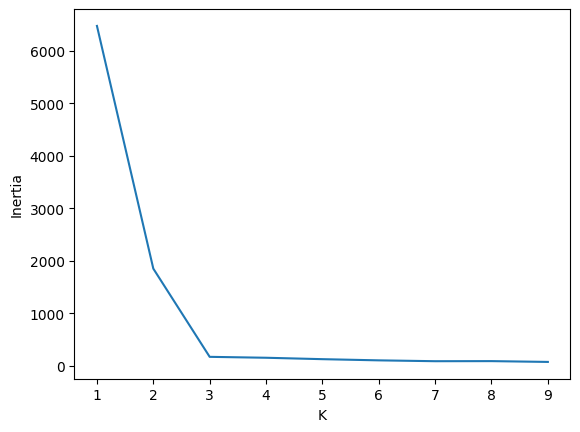

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=100, centers=3, random_state=42)

inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

**Key Observation**
* From K = 1 → 3 → massive improvement
* After K = 3 → very small improvement

So Best K = 3

**Because:**
* Before K=3 → model is improving a LOT
* After K=3 → adding clusters doesn’t help much

### **5.3 Hierarchical Clustering (AgglomerativeClustering)**

**Syntax**
```bash
model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward',
    metric='euclidean'
)
```

**Parameters (simple language)**
* n_clusters ⭐
    * number of clusters to form
* linkage → 'ward', 'complete', 'average', 'single' ⭐
    * how clusters are merged
    * 'ward' = minimizes variance (most used)
* metric → 'euclidean', 'manhattan', etc.
    * distance measure between points

**Important Note**
* No predict() method
* Use only: fit_predict() ⭐

In [ ]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Small dataset
X = np.array([
    [1, 2], [1, 3], [2, 2],
    [8, 8], [9, 8], [8, 9]
])

# Create model
model = AgglomerativeClustering(n_clusters=2)

# Fit & Predict (no separate predict method)
labels = model.fit_predict(X)
print("Cluster labels:", labels)

Cluster labels: [1 1 1 0 0 0]


### **5.4 DBSCAN (Density-Based)**

**Syntax**
```bash
model = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric='euclidean'
)
```

**Parameters (simple language)**
* eps ⭐
    * maximum distance between two points to be considered neighbors
* min_samples ⭐
    * minimum points required to form a cluster
* metric → 'euclidean', 'manhattan', etc.
    * distance measure used

In [30]:
import numpy as np
from sklearn.cluster import DBSCAN

# Small dataset
X = np.array([
    [1, 2], [1, 3], [2, 2],
    [8, 8], [9, 8], [8, 9],
    [50, 50]   # noise point
])

# Create model
model = DBSCAN(eps=2, min_samples=2)

# Fit & Predict
labels = model.fit_predict(X)

print("Cluster labels:", labels)

Cluster labels: [ 0  0  0  1  1  1 -1]


**Output:**
* Cluster labels (0,1,2...)
* -1 = noise (outlier)

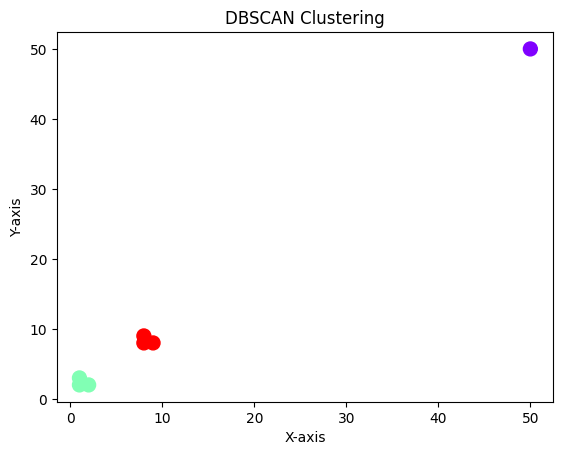

In [32]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=model.labels_, cmap='rainbow', s=100)
plt.title("DBSCAN Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()
plt.show()